In [20]:
import joblib
import os
import pandas as pd
import numpy as np

# Loading the trained tree models from directory.

TARGET_DIR = r"C:\Python DAT540\Dat-540-Prosjekt\data\tree_models"

# List of filenames
model_filenames = [
    'dt_baseline_model.joblib',
    'dt_tuned_model_1_CV3.joblib',
    'dt_tuned_model_2_CV5.joblib',
    'dt_tuned_model_3_CV10.joblib',
    'dt_tuned_model_4_CV3_3.joblib',
    'dt_tuned_model_5_CV3_5.joblib',
    'dt_tuned_model_6_CV5_5.joblib',
    'rf_baseline_model.joblib',
    'rf_tuned_model_1.joblib',
    'rf_tuned_model_2.joblib',
    'rf_tuned_model_3.joblib',
    'rf_tuned_model_4.joblib',
    'rf_tuned_model_5.joblib',
    'rf_tuned_model_6.joblib'
]


# Initialize a dictionary to store the loaded models
loaded_models = {}

print("Loading models from disk...")

# Iterate, load, and store
for filename in model_filenames:
    # Construct the full path
    full_path = os.path.join(TARGET_DIR, filename)
    
    # Load the model
    model = joblib.load(full_path)
    
    # Create a clean key for the dictionary 
    model_key = filename.replace('.joblib', '')
    
    # Store the loaded model in the dictionary
    loaded_models[model_key] = model
    print(f"Loaded: {model_key}")

print("\nAll models loaded successfully into the 'loaded_models' dictionary.")

# Load processed data
X_train = np.load("../data/processed/X_train_scaled.npy")
X_valid = np.load("../data/processed/X_valid_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")
y_valid = np.load("../data/processed/y_valid.npy")
feature_names = pd.read_csv("../data/processed/feature_names.csv", header=None)[0].tolist()

Loading models from disk...
Loaded: dt_baseline_model
Loaded: dt_tuned_model_1_CV3
Loaded: dt_tuned_model_2_CV5
Loaded: dt_tuned_model_3_CV10
Loaded: dt_tuned_model_4_CV3_3
Loaded: dt_tuned_model_5_CV3_5
Loaded: dt_tuned_model_6_CV5_5
Loaded: rf_baseline_model
Loaded: rf_tuned_model_1
Loaded: rf_tuned_model_2
Loaded: rf_tuned_model_3
Loaded: rf_tuned_model_4
Loaded: rf_tuned_model_5
Loaded: rf_tuned_model_6

All models loaded successfully into the 'loaded_models' dictionary.


In [59]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix, log_loss, make_scorer
from matplotlib import pyplot as plt
import seaborn as sns

# Define the formatted names list and map it to the dictionary keys
model_name_mapping = {
    'dt_baseline_model': 'Baseline\nDecision Tree',
    'dt_tuned_model_1_CV3': 'Tuned Decision\nTree (CV=3)', 
    'dt_tuned_model_2_CV5': 'Tuned Decision\nTree (CV=5)', 
    'dt_tuned_model_3_CV10': 'Tuned Decision\nTree (CV=10)',
    'dt_tuned_model_4_CV3_3': 'Tuned Decision\nTree\n(CV=3, 3 repeats)',
    'dt_tuned_model_5_CV3_5': 'Tuned Decision\nTree\n(CV=3, 5 repeats)',
    'dt_tuned_model_6_CV5_5': 'Tuned Decision\nTree\n(CV=5, 5 repeats)',
    'rf_baseline_model': 'Baseline\nRandom Forest',
    'rf_tuned_model_1': 'Tuned Random\nForest (CV=2,\n60 candidates)\nBalanced Accuracy',
    'rf_tuned_model_2': 'Tuned Random\nForest (CV=3,\n60 candidates)\nBalanced Accuracy',
    'rf_tuned_model_3': 'Tuned Random\nForest (CV=3,\n200 candidates)\nBalanced Accuracy',
    'rf_tuned_model_4': 'Tuned Random\nForest (15 evals,\n200 candidates)\nBalanced Accuracy',
    'rf_tuned_model_5': 'Tuned Random\nForest (9 evals,\n200 candidates)\nAuc scoring',
    'rf_tuned_model_6': 'Tuned Random\nForest (15 evals,\n200 candidates)\nAuc scoring',
}



# Initilize results_data to store the scoring metrics from the different models
results_data = []

# Function to store scoring metrics from a specified model
def store_metrics(model, name, X_valid, y_valid):
    # Get predictions and probabilities
    y_pred = model.predict(X_valid)
    y_prob = model.predict_proba(X_valid)[:, 1]
    y_proba_all = model.predict_proba(X_valid)
    
    # Calculate specificity
    cm = confusion_matrix(y_valid, y_pred)
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    # Append metrics to result_data
    results_data.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_valid, y_pred),
        'Test AUC': roc_auc_score(y_valid, y_prob),
        'Log Loss': log_loss(y_valid, y_proba_all),
        'Specificity': specificity, 
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP
    })

# Iterate through the mapping and call store_metrics
print("Extracting metrics from loaded models...")

for model_key, display_name in model_name_mapping.items():
    # Access the loaded model object using the key
    model_object = loaded_models[model_key] 
    
    # Run the evaluation
    store_metrics(model_object, display_name, X_valid, y_valid)
    print(f"Metrics stored for: {model_key}")

# Create the final DataFrame
df_results = pd.DataFrame(results_data)


Extracting metrics from loaded models...
Metrics stored for: dt_baseline_model
Metrics stored for: dt_tuned_model_1_CV3
Metrics stored for: dt_tuned_model_2_CV5
Metrics stored for: dt_tuned_model_3_CV10
Metrics stored for: dt_tuned_model_4_CV3_3
Metrics stored for: dt_tuned_model_5_CV3_5
Metrics stored for: dt_tuned_model_6_CV5_5
Metrics stored for: rf_baseline_model
Metrics stored for: rf_tuned_model_1
Metrics stored for: rf_tuned_model_2
Metrics stored for: rf_tuned_model_3
Metrics stored for: rf_tuned_model_4
Metrics stored for: rf_tuned_model_5
Metrics stored for: rf_tuned_model_6


In [35]:
def plot_model_metrics(df_data, title):
    
    plt.figure(figsize=(14,8)) 
    sns.set_style("whitegrid")

    # Create a bar plot, using 'Metric' for columns and 'Model' for the x-axis
    ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df_data)

    # Add labels and title
    plt.title(title, fontsize=16)
    plt.ylabel('Score Value', fontsize=12)
    plt.xlabel('Model', fontsize=12)
    plt.xticks(ha='center', fontsize=14) 

    # Add the score values on top of the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 7), # Adjusted xytext slightly
                    textcoords='offset points',
                    fontsize=9) # Adjusted font size for more space

    plt.tight_layout()
    plt.show()

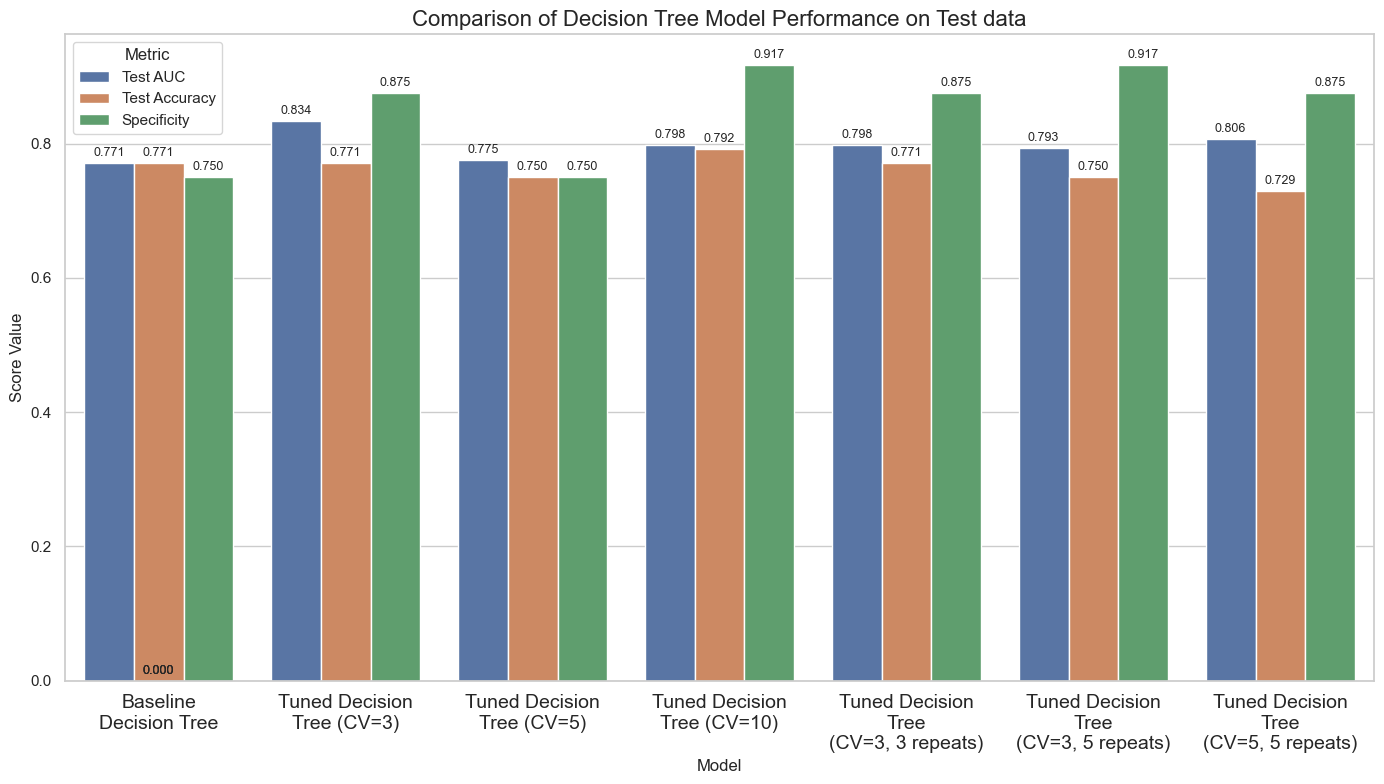

In [53]:
# Select the result data for the Decision Tree models

dt_df_plot_primary = df_results.iloc[:7,:].melt(id_vars='Model', 
                                  value_vars=['Test AUC', 'Test Accuracy', 'Specificity'],
                                  var_name='Metric', 
                                  value_name='Score')

plot_model_metrics(dt_df_plot_primary, title='Comparison of Decision Tree Model Performance on Test data')

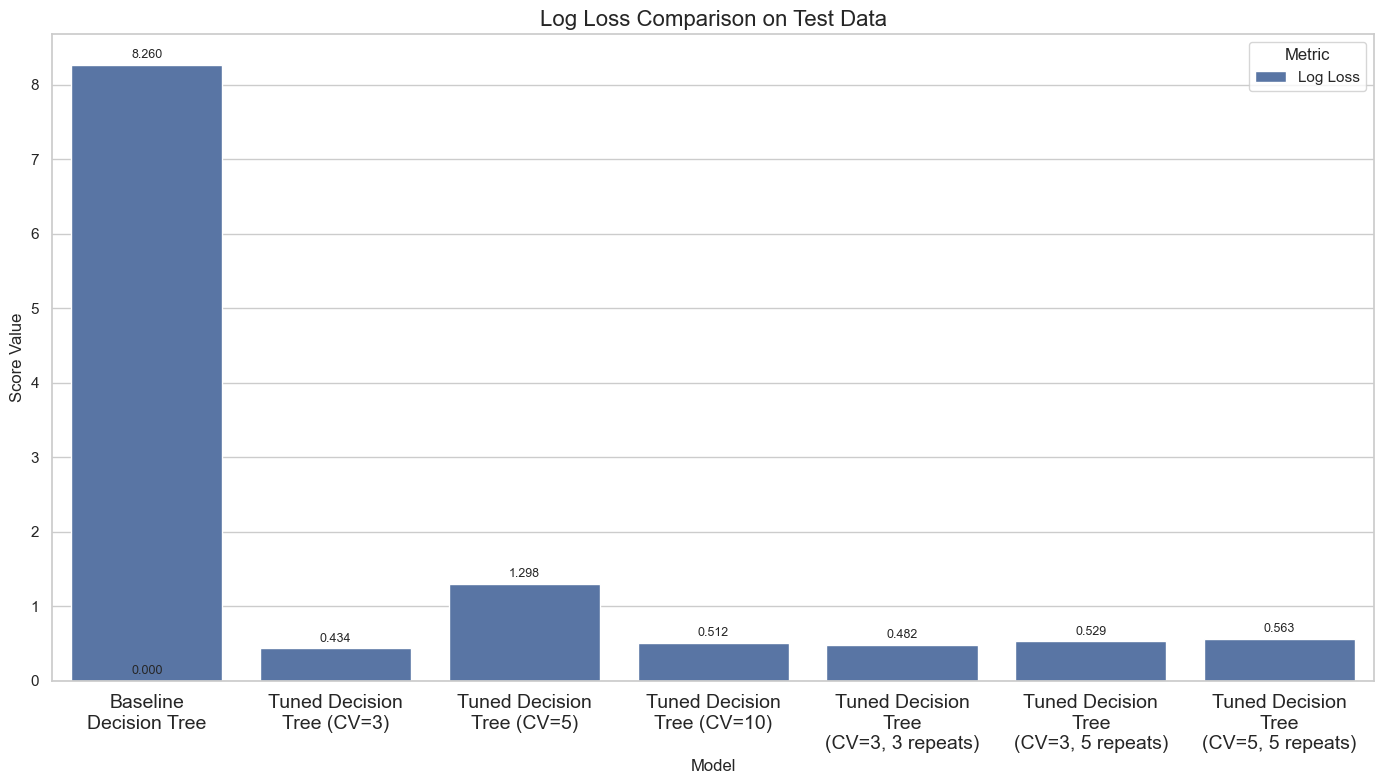

In [54]:
dt_df_plot_logloss = df_results.iloc[:7,:].melt(id_vars='Model', 
                                  value_vars=['Log Loss'],
                                  var_name='Metric', 
                                  value_name='Score')

plot_model_metrics(dt_df_plot_logloss, title='Log Loss Comparison on Test Data') 

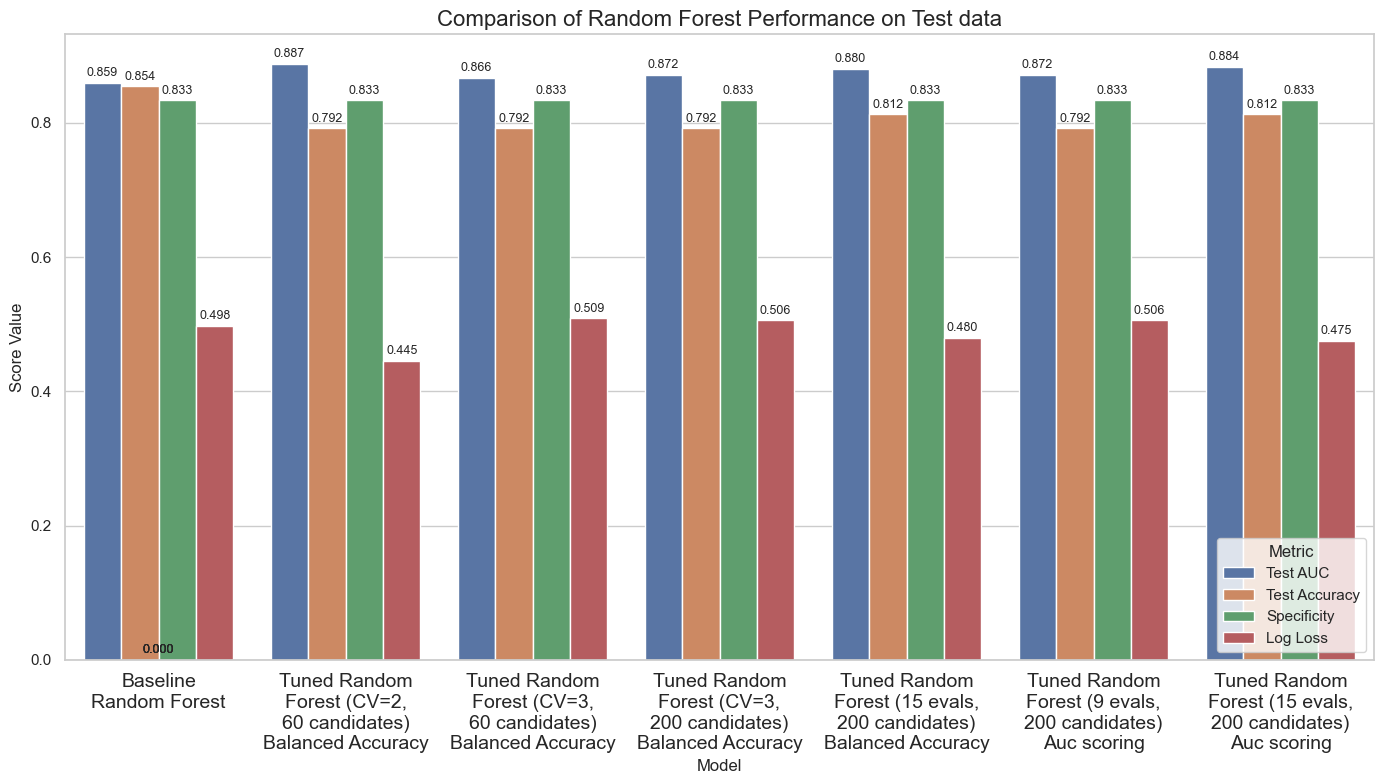

In [61]:
# Select the result data for the Random Forest models

rf_df_plot_primary = df_results.iloc[7:,:].melt(id_vars='Model', 
                                  value_vars=['Test AUC', 'Test Accuracy', 'Specificity', 'Log Loss'],
                                  var_name='Metric', 
                                  value_name='Score')

plot_model_metrics(rf_df_plot_primary, title='Comparison of Random Forest Performance on Test data')

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score 
from matplotlib import pyplot as plt

# Plots ROC curves for multiple trained classification models.

def plot_roc_curves(model_keys, model_display_names, X_valid, y_valid, loaded_models,
                    figsize=(9, 9), title='Receiver Operating Characteristic (ROC) Curve Comparison',
                    show=True):
    
    # Basic setup 
    plt.figure(figsize=figsize)
    plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')  # Baseline diagonal

    # Iterate through selected models
    for key, name in zip(model_keys, model_display_names):
        model = loaded_models[key]
        
        # Predict probabilities for the positive class
        y_prob = model.predict_proba(X_valid)[:, 1]
        
        # Calculate ROC curve and AUC
        fpr, tpr, _ = roc_curve(y_valid, y_prob)
        auc = roc_auc_score(y_valid, y_prob)
        
        # Plot
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

    # Final formatting
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity / Recall)')
    plt.title(title, fontsize=14)
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True)
    if show:
        plt.show()

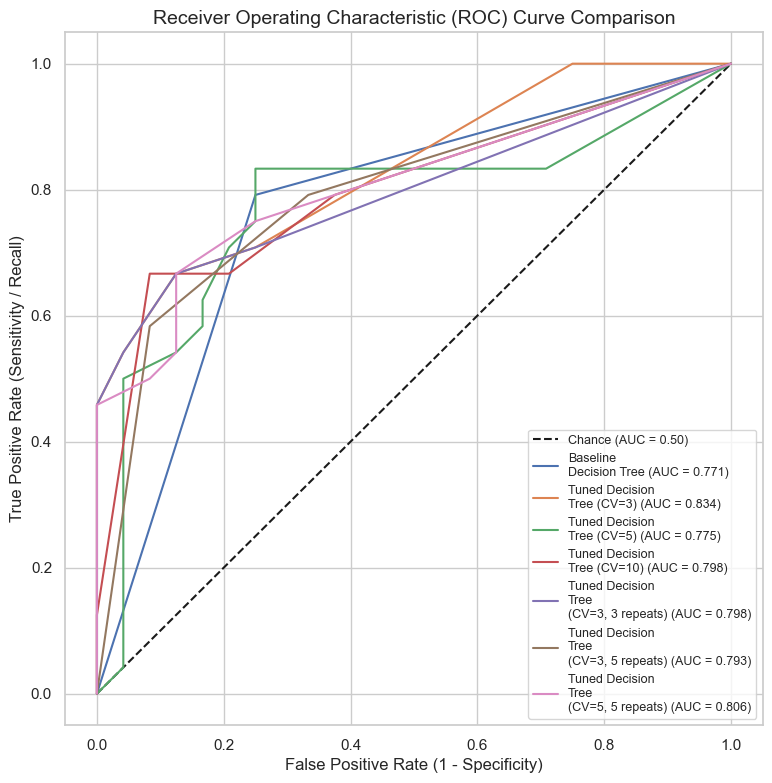

In [50]:
# Get the model keys and display names from model name mapping

model_keys = list(model_name_mapping.keys())
model_display_names = list(model_name_mapping.values())

# Plot ROC curves for the Decision Tree models

dt_keys = model_keys[:7]
dt_names = [model_name_mapping[k] for k in dt_keys]

plot_roc_curves(
    model_keys=dt_keys,
    model_display_names=dt_names,
    X_valid=X_valid,
    y_valid=y_valid,
    loaded_models=loaded_models
)

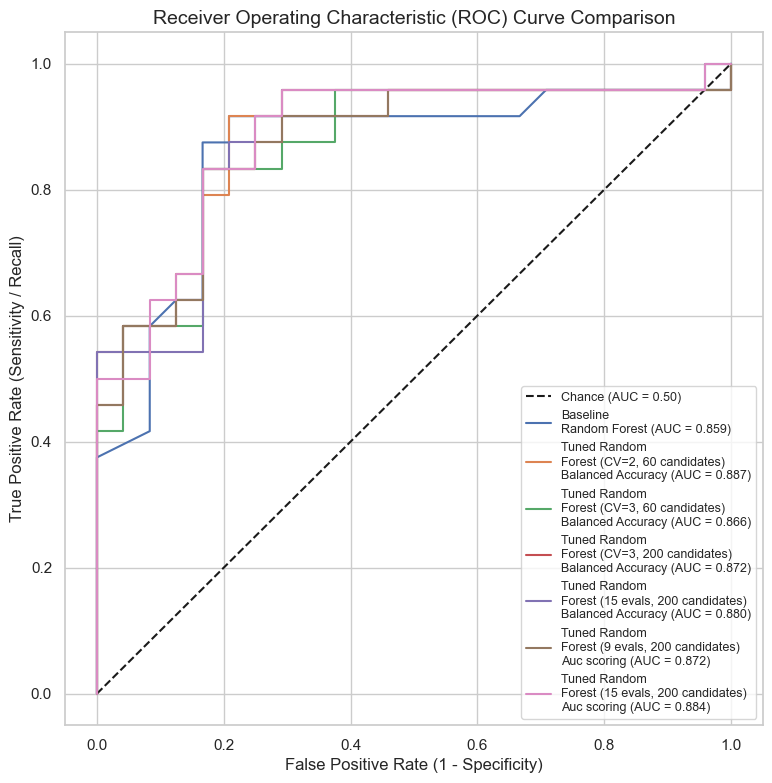

In [52]:
# Get the model keys and display names from model name mapping

model_keys = list(model_name_mapping.keys())
model_display_names = list(model_name_mapping.values())

# Plot ROC curves for the Random Forest models

rf_keys = model_keys[7:]
rf_names = [model_name_mapping[k] for k in rf_keys]

plot_roc_curves(
    model_keys=rf_keys,
    model_display_names=rf_names,
    X_valid=X_valid,
    y_valid=y_valid,
    loaded_models=loaded_models
)

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Define a function to plot confusion matrices for selected models

def plot_confusion_matrices(model_keys, model_display_names, X_valid, y_valid, loaded_models,
                            x_labels=('No Gallstone', 'Gallstone'),
                            y_labels=('No Gallstone', 'Gallstone'),
                            title='Confusion Matrix Comparison',
                            figsize=(18, 9),
                            cmap='Blues'):


    n_models = len(model_keys)
    n_cols = min(4, n_models)
    n_rows = int(np.ceil(n_models / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    sns.set(font_scale=1.0)

    for i, key in enumerate(model_keys):
        model = loaded_models[key]
        display_name = model_display_names[i]

        # Generate predictions and confusion matrix
        y_pred = model.predict(X_valid)
        cm = confusion_matrix(y_valid, y_pred)

        # Plot heatmap
        ax = axes[i]
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                    ax=ax, xticklabels=x_labels, yticklabels=y_labels)

        # Set title
        ax.set_title(display_name, fontsize=12)

        # Label only leftmost column plots
        if i % n_cols == 0:
            ax.set_ylabel('Actual Gallstone Status', fontsize=11)
        else:
            ax.set_ylabel('')
            ax.set_yticklabels([])  # hide repeated y-labels for cleaner layout

        # X-axis labels
        ax.set_xlabel('Predicted Gallstone Status', fontsize=11)
        ax.set_xticklabels(x_labels, rotation=0, fontsize=10)
        ax.tick_params(axis='y', labelrotation=90, labelsize=10)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title, y=1.02, fontsize=18)
    plt.tight_layout()
    plt.show()

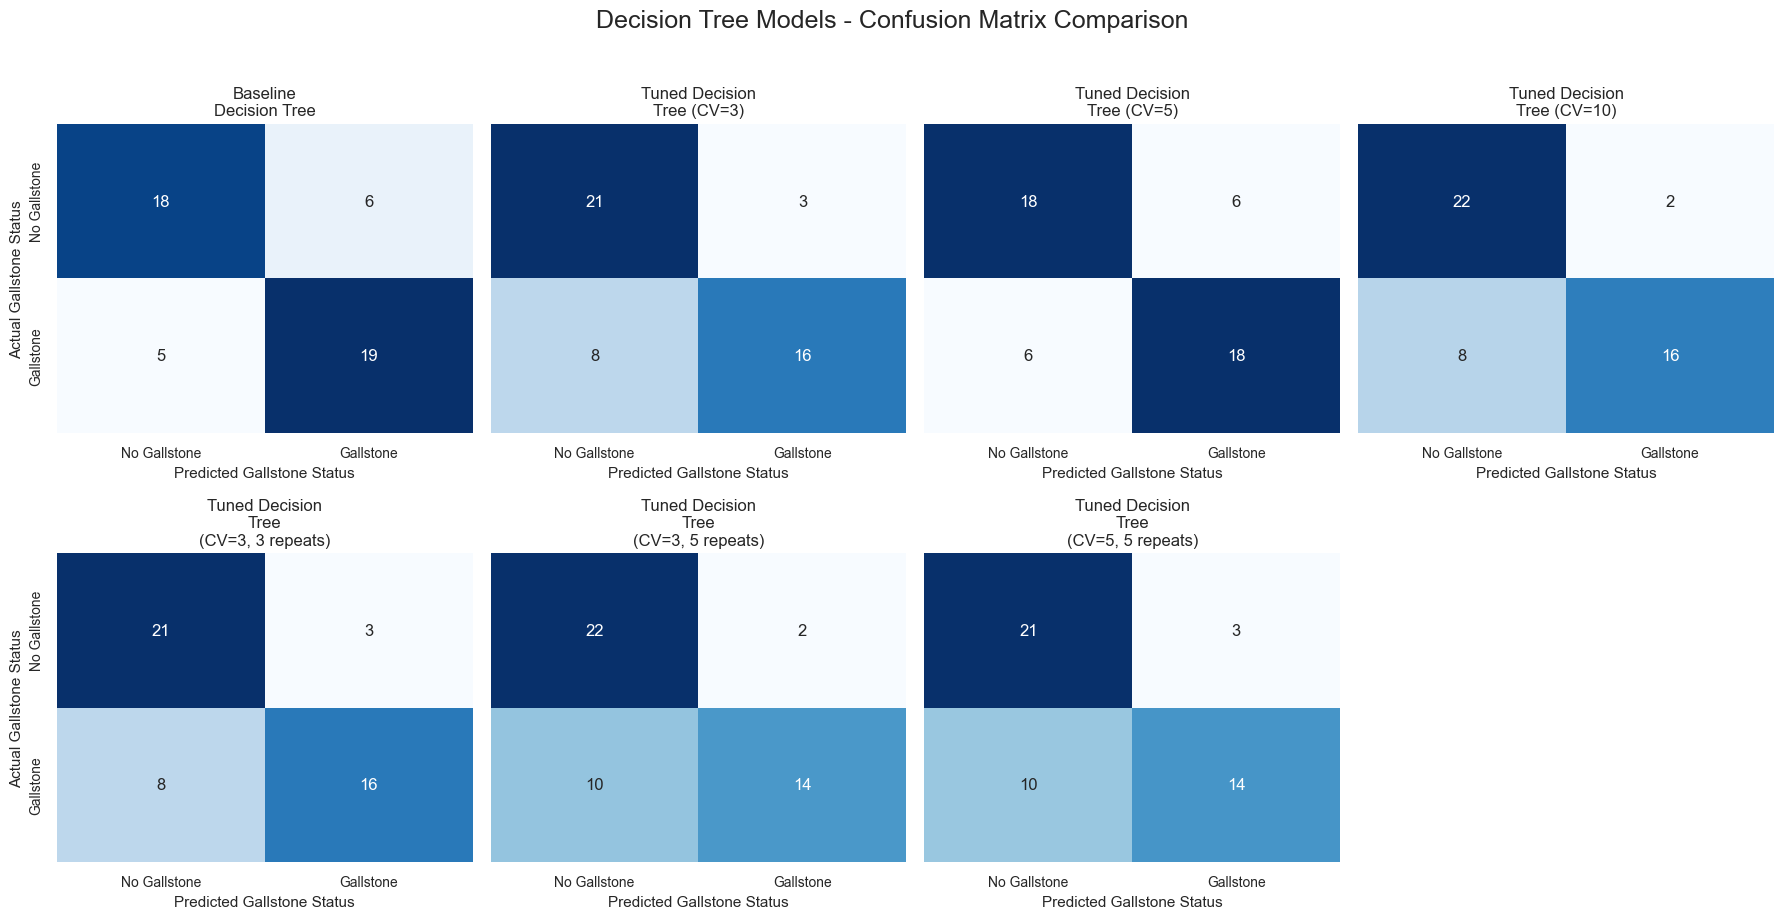

In [69]:
# Plot confusion matrices for Decision Tree models

plot_confusion_matrices(
    model_keys=dt_keys,
    model_display_names=dt_names,
    X_valid=X_valid,
    y_valid=y_valid,
    loaded_models=loaded_models,
    title='Decision Tree Models - Confusion Matrix Comparison'
)

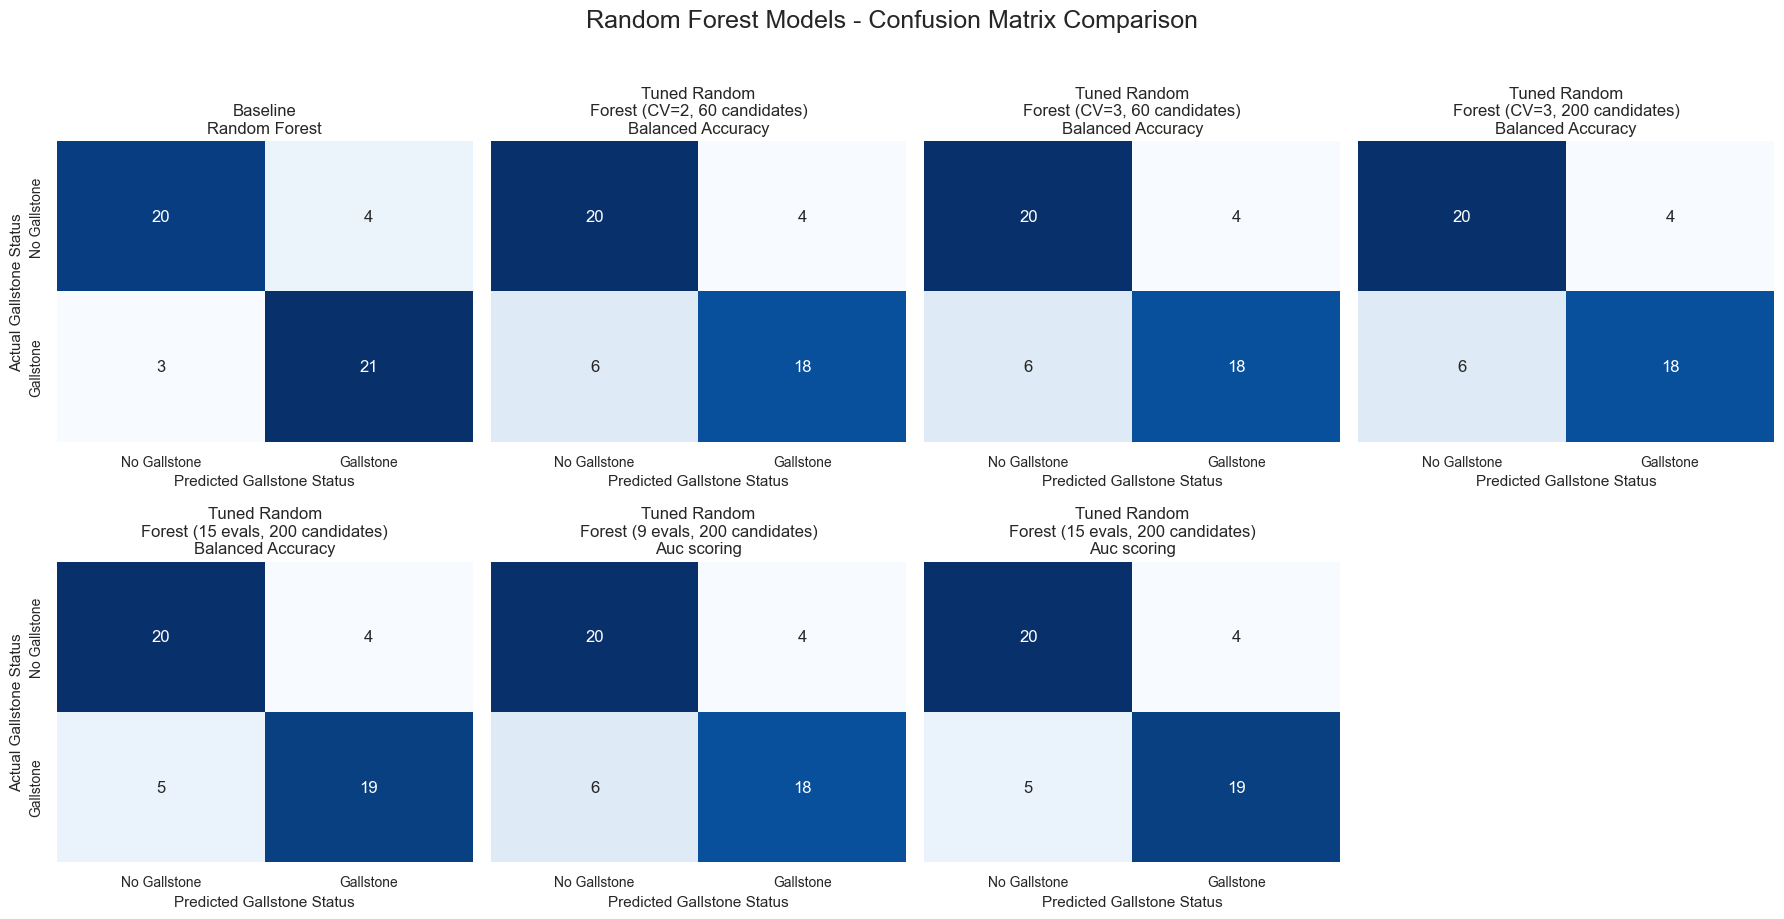

In [70]:
# Plot confusion matrices for Random Forest models

plot_confusion_matrices(
    model_keys=rf_keys,
    model_display_names=rf_names,
    X_valid=X_valid,
    y_valid=y_valid,
    loaded_models=loaded_models,
    title='Random Forest Models - Confusion Matrix Comparison'
)